# به نام خدا

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
tips_df = sns.load_dataset('tips')

In [69]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [70]:
# مشخصات
tips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# Handling Missing Values

In [71]:
# check for missing values
tips_df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

# Exploratory Data Analysis (EDA)

<Axes: xlabel='tip', ylabel='Count'>

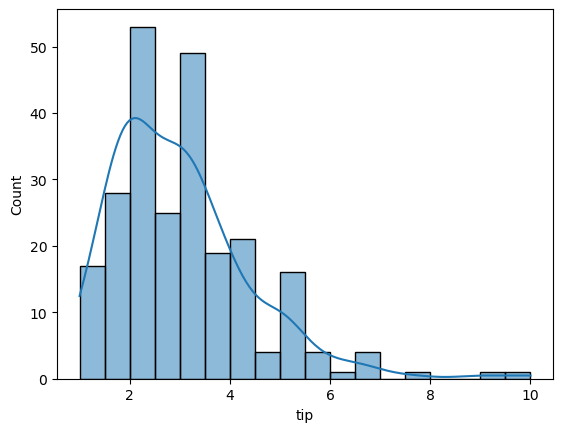

In [72]:
# Distribution of tip amounts
sns.histplot(tips_df['tip'], kde=True)

<div dir='rtl'>

**مشاهدات:**
- بیشتر افراد 1.5 تا 4 دلار انعام دادند
- توزیع Right-skewed یا Positively Skewed

Text(0.5, 1.0, 'Total_bill vs Tip')

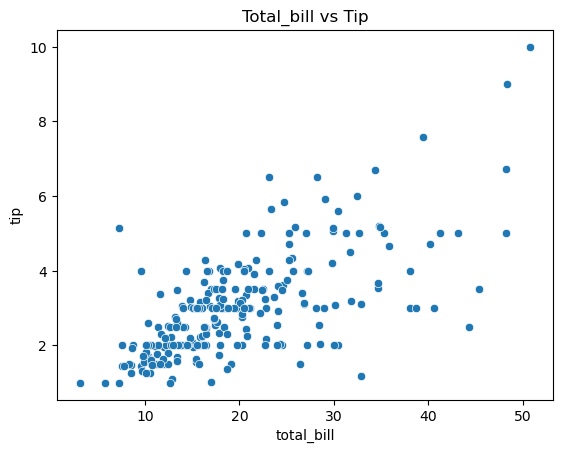

In [73]:
sns.scatterplot(x='total_bill', y='tip', data=tips_df)
plt.title('Total_bill vs Tip')

<div dir='rtl'>

**مشاهدات:**

- یک رابطه **خطی مثبت** بین صورتحساب و انعام دیده می‌شود: با افزایش صورتحساب، انعام هم به‌طور کلی افزایش می‌یابد.
- اما نقاط به‌طور کامل روی یک خط قرار ندارند؛ یعنی `total_bill` تنها عامل تعیین‌کننده انعام نیست.

<Axes: xlabel='smoker', ylabel='tip'>

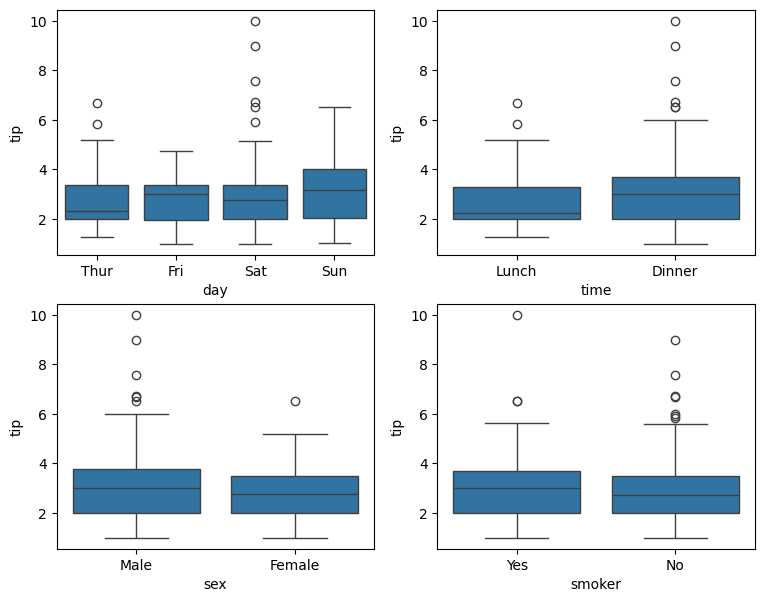

In [74]:
# بررسی تأثیر متغیرهای کیفی بر روی مقدار انعام
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
sns.boxplot(data=tips_df, x='day', y='tip', ax=axes[0, 0])
sns.boxplot(data=tips_df, x='time', y='tip', ax=axes[0, 1])
sns.boxplot(data=tips_df, x='sex', y='tip', ax=axes[1, 0])
sns.boxplot(data=tips_df, x='smoker', y='tip', ax=axes[1, 1])

<div dir='rtl'>

**مشاهدات:**

- **روز هفته:** انعام در روز یکشنبه(sunday) بالاترین میانه را دارد.
- **نوع وعده:** شام (Dinner) انعام بیشتری نسبت به ناهار (Lunch) دارد. پراکندگی در شام هم بیشتر است.
- **سیگاری بودن:** تفاوت معناداری بین سیگاری و غیرسیگاری دیده نمی‌شود. این متغیر احتمالاً تأثیر کمی بر مدل دارد.
- **جنسیت:** تفاوت میانه مرد و زن کم است. احتمالاً این متغیر هم تأثیر قوی‌ای ندارد.

**نتیجه برای مدل‌سازی:**

- متغیرهای `day` و `time` احتمالاً باید در مدل بمانند.
- متغیرهای `smoker` و `sex` ممکن است نامزدهایی برای حذف از مدل باشند.

</div>

# Feature Encoding

In [75]:
# Categorical encoding for 'sex', 'smoker', and 'time'
tips_df['sex'] = tips_df['sex'].cat.codes
tips_df['time'] = tips_df['time'].cat.codes
tips_df['smoker'] = tips_df['smoker'].cat.codes

# One-hot encoding for 'day'
tips_df = pd.get_dummies(tips_df, columns=['day'], prefix='day')
tips_df.head()

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,1,2,False,False,False,True
1,10.34,1.66,0,1,1,3,False,False,False,True
2,21.01,3.50,0,1,1,3,False,False,False,True
3,23.68,3.31,0,1,1,2,False,False,False,True
4,24.59,3.61,1,1,1,4,False,False,False,True


<div dir='rtl'>

⚠️ **نکته مهم:** ما از کدهای دسته‌بندی برای «جنسیت»، «سیگاری» و «زمان» استفاده می‌کنیم زیرا آنها باینری هستند.اما برای «روز»، از کدگذاری one-hot استفاده می‌کنیم تا از ترتیب بین روزها جلوگیری شود.

# Preparing for Modeling

In [76]:
# separate our features and target variable
X = tips_df.drop(columns='tip')
y = tips_df['tip']

print('Feature:', X.columns)
print('Target:', y.name)

Feature: Index(['total_bill', 'sex', 'smoker', 'time', 'size', 'day_Thur', 'day_Fri',
       'day_Sat', 'day_Sun'],
      dtype='object')
Target: tip


# Correlation Analysis

In [77]:
tips_df.corr()['tip'].sort_values(ascending=False)

tip           1.000000
total_bill    0.675734
size          0.489299
day_Sun       0.125114
time          0.121629
day_Sat      -0.002790
smoker       -0.005929
day_Fri      -0.055463
sex          -0.088862
day_Thur     -0.095879
Name: tip, dtype: float64

# Selecting Initial Features

In [78]:
# انتخاب ویژگی‌های مهم
selected_features = ['total_bill', 'size', 'time','day_Sun', 'day_Sat']
X_selected = tips_df[selected_features]
X_selected.head()

,total_bill,size,time,day_Sun,day_Sat
0,16.99,2,1,True,False
1,10.34,3,1,True,False
2,21.01,3,1,True,False
3,23.68,2,1,True,False
4,24.59,4,1,True,False


# Feature Engineering

In [79]:
# create some new features that might improve our model
tips_df['tip_percentage'] = tips_df['tip'] / tips_df['total_bill'] * 100 # درصد انعام نسبت به مبلغ کل صورت‌حساب
tips_df['per_person_total'] = tips_df['total_bill'] / tips_df['size'] # مبلغ صورت‌حساب به ازای هر نفر
tips_df['is_weekend'] = tips_df['day_Sat'] | tips_df['day_Sun']
tips_df['party_size_category'] = pd.cut(tips_df['size'], bins=[0, 3, 6, np.inf], labels=['Small', 'Medium', 'Large'])
tips_df = pd.get_dummies(tips_df, columns=['party_size_category'], prefix='party')
tips_df 

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True,True,False,False
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True,True,False,False
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True,True,False,False
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True,True,False,False
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True,True,False,False
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True,True,False,False
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True,True,False,False
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True,True,False,False


# Updating Selected Features

In [80]:
tips_df.corr()['tip'].sort_values(ascending=False)

tip                 1.000000
total_bill          0.675734
size                0.489299
party_Medium        0.425938
per_person_total    0.347393
tip_percentage      0.342370
day_Sun             0.125114
time                0.121629
is_weekend          0.120198
day_Sat            -0.002790
smoker             -0.005929
day_Fri            -0.055463
sex                -0.088862
day_Thur           -0.095879
party_Small        -0.425938
party_Large              NaN
Name: tip, dtype: float64

In [81]:
selected_features = ['total_bill', 'size', 'time', 'day_Sat', 'day_Sun', 'tip_percentage',
                     'per_person_total', 'is_weekend', 'party_Small', 'party_Medium', 'party_Large']
X_selected = tips_df[selected_features]
X_selected

,total_bill,size,time,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,2,1,False,True,5.944673,8.495000,True,True,False,False
1,10.34,3,1,False,True,16.054159,3.446667,True,True,False,False
2,21.01,3,1,False,True,16.658734,7.003333,True,True,False,False
3,23.68,2,1,False,True,13.978041,11.840000,True,True,False,False
4,24.59,4,1,False,True,14.680765,6.147500,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,3,1,True,False,20.392697,9.676667,True,True,False,False
240,27.18,2,1,True,False,7.358352,13.590000,True,True,False,False
241,22.67,2,1,True,False,8.822232,11.335000,True,True,False,False
242,17.82,2,1,True,False,9.820426,8.910000,True,True,False,False


# Preparing Final Dataset for Modeling

In [82]:
from sklearn.model_selection import train_test_split

# مطمئن میشیم همه چی عدده
X = X_selected.astype(np.float64)
y = tips_df['tip'].astype(np.float64)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (195, 11)
Testing set shape: (49, 11)


In [83]:
# بررسی صحت تقسیم داده به آموزش و تست
assert X_train.shape[0] + X_test.shape[0] == tips_df.shape[0], "Training and testing sets do not match the original dataset size"
assert X_train.shape[1] == X_test.shape[1], "Training and testing sets do not have the same number of features"

# Implementing Multiple Linear Regression

In [84]:
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Examining the Model

In [85]:
# نمایش ضرایب مدل رگرسیون خطی بعد از آموزش
print('Intercept:', lr_model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
print(coef_df.sort_values('Coefficient', ascending=False))

Intercept: -2.2863403828206463
             Feature  Coefficient
1               size     0.155527
5     tip_percentage     0.146666
0         total_bill     0.129741
3            day_Sat     0.037923
9       party_Medium     0.015805
6   per_person_total     0.009665
10       party_Large     0.000000
8        party_Small    -0.015805
7         is_weekend    -0.035366
2               time    -0.070779
4            day_Sun    -0.073289


# Visualizing Predictions

Text(0.5, 1.0, 'Actual vs Predicted Tips (Test Set)')

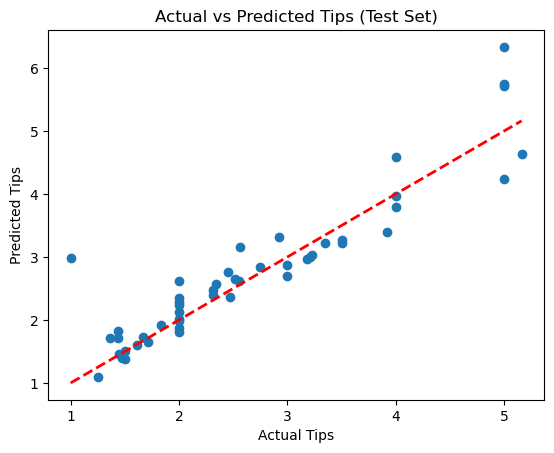

In [86]:
# مدل روی داده تست پیش‌بینی می‌کند
y_test_pred = lr_model.predict(X_test)

# نمودار پراکندگی واقعی در مقابل پیش‌بینی
plt.scatter(y_test, y_test_pred)

# The 45-degree line or the line y = x
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Actual vs Predicted Tips (Test Set)")

<div dir='rtl'>

**مشاهدات:** نقاطی که به خط قرمز نزدیک‌ترند، نشان‌دهنده پیش‌بینی‌های دقیق‌تری هستند. انحراف از این خط، نقاطی را نشان می‌دهد که پیش‌بینی‌های مدل ما در آن‌ها دچار خطا شده است.

# Residual Analysis

Text(0.5, 1.0, 'Residual Plot (Test Set)')

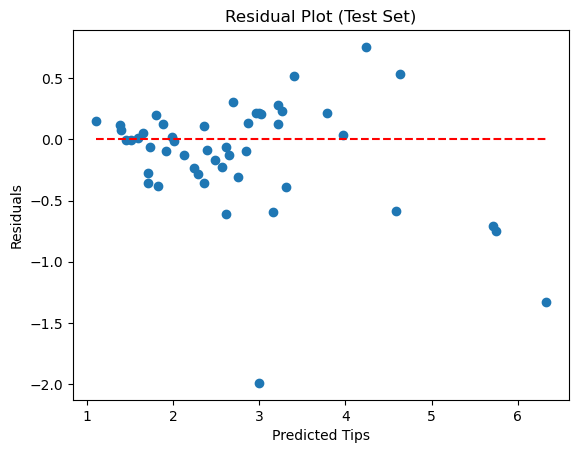

In [87]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), colors='r', linestyles='--')
plt.xlabel("Predicted Tips")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set)")


<div dir='rtl'>

**تحلیل باقیمانده‌ها (Residual Analysis):**

- Residualها به‌طور تصادفی حول خط صفر پراکنده‌اند → فرض خطی بودن تقریباً برقرار است.
- پراکندگی در مقادیر بالا بیشتر است → Heteroscedasticity خفیف.
- چند Residual پرت وجود دارد → مدل برای چند مشتری خاص ضعیف بوده.
- روند کلی: تصادفی حول صفر است (خوب!).

</div>

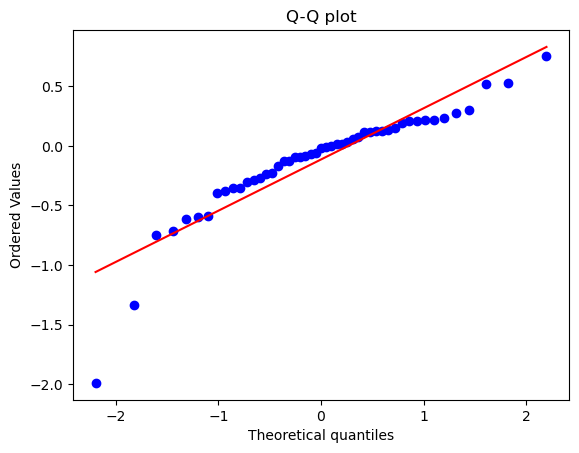

In [88]:
import scipy.stats as stats

fig, ax = plt.subplots()
stats.probplot(y_test - y_test_pred, plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

<div dir='rtl'>

چه قدر به توزیع نرمال نزدیک است؟ جواب ---> خوب!